In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("../src").resolve()))
sys.path.append(str(Path("../utils").resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from data_loader import load_all_data, merge_commodities
from validation import validate_dataset

In [2]:
commodities = load_all_data()

gold = commodities["gold"]
silver = commodities["silver"]
oil = commodities["crude_oil"]
gas = commodities["natural_gas"]
copper = commodities["copper"]

merged = merge_commodities(commodities)

Max Drawdown Analysis

In [3]:
from analytics import (
    calculate_drawdown,
    maximum_drawdown
)

In [4]:
gold_dd = calculate_drawdown(gold)

maximum_drawdown(gold_dd)

np.float64(-24.9717937331179)

In [5]:
from visualisation import plot_drawdown

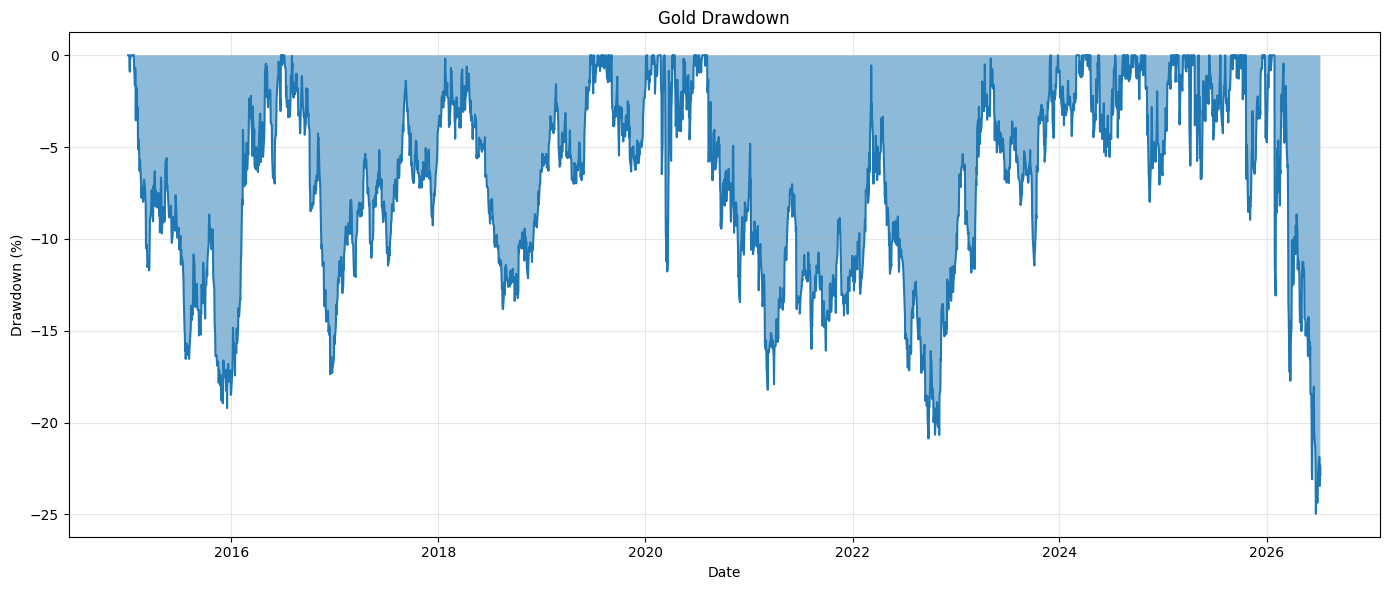

In [6]:
plot_drawdown(
    gold_dd,
    "Gold"
)

In [7]:
drawdown_data = {}

summary = []

for name, df in commodities.items():

    temp = calculate_drawdown(df)

    drawdown_data[name] = temp

    summary.append({
        "Commodity": name,
        "Maximum Drawdown (%)": round(
            maximum_drawdown(temp),
            2
        )
    })

drawdown_summary = pd.DataFrame(summary)

drawdown_summary

,Commodity,Maximum Drawdown (%)
0,gold,-24.97
1,silver,-49.56
2,crude_oil,-149.25
3,natural_gas,-83.73
4,copper,-35.64


# Maximum Drawdown Analysis

## Business Question

While return measures how much an investment gained over time, investors are equally concerned with the largest decline experienced before the asset recovered.

This downside risk is measured using **Maximum Drawdown (MDD)**, one of the most widely used risk metrics in portfolio management.

---

## What is Maximum Drawdown?

Maximum Drawdown represents the **largest percentage decline from a historical peak to the subsequent lowest point** before a new peak is reached.

It captures the worst loss an buy-and-hold investor could have experienced during the analysis period.

Mathematically,

\[
\text{Drawdown}=
\frac{\text{Current Price}-\text{Previous Peak}}
{\text{Previous Peak}}
\]

The most negative value observed over the entire time series is called the **Maximum Drawdown**.

Unlike volatility, which measures day-to-day fluctuations, maximum drawdown focuses on the magnitude of prolonged losses, making it an intuitive measure of downside risk.

---

## Maximum Drawdown Results

| Commodity | Maximum Drawdown |
|-----------|-----------------:|
| Gold | **-24.97%** |
| Silver | **-49.56%** |
| Crude Oil | **-149.25%** |
| Natural Gas | **-83.73%** |
| Copper | **-35.64%** |

---

## Commodity-wise Interpretation

### Gold

Gold experienced the smallest drawdown among all commodities, declining by approximately **25%** from its historical peak.

Although temporary corrections occurred throughout the sample period, gold consistently recovered and established new highs, reinforcing its role as a relatively defensive investment.

---

### Silver

Silver recorded a maximum drawdown of nearly **50%**, almost double that of gold.

This reflects silver's higher sensitivity to market sentiment and industrial demand, leading to much larger corrections despite its strong long-term returns.

---

### Crude Oil

Crude oil experienced the most severe drawdown (**−149.25%**).

This extraordinary value is explained by the historic **negative WTI oil prices during April 2020**, when futures contracts traded below zero due to collapsing demand and storage shortages during the COVID-19 pandemic.

The negative drawdown illustrates the exceptional downside risk associated with energy markets during extreme market disruptions.

---

### Natural Gas

Natural gas suffered an **83.73%** drawdown.

Despite several sharp rallies, prices repeatedly collapsed after supply conditions normalized, highlighting the commodity's cyclical and highly volatile nature.

---

### Copper

Copper recorded a maximum drawdown of approximately **36%**.

Compared with other industrial commodities, copper demonstrated relatively moderate downside risk and recovered strongly as global industrial activity improved.

---

## Comparative Insights

Ranking commodities by downside risk:

| Rank | Commodity | Downside Risk |
|------|-----------|--------------:|
| 1 | Gold | Lowest |
| 2 | Copper | Low |
| 3 | Silver | Moderate |
| 4 | Natural Gas | High |
| 5 | Crude Oil | Extreme |

---

## Key Business Insights

The maximum drawdown analysis complements the earlier return and volatility metrics by quantifying the worst historical losses investors could have experienced.

- **Gold** exhibited the lowest downside risk, reinforcing its reputation as a defensive asset and portfolio stabilizer.
- **Copper** maintained relatively moderate drawdowns while delivering solid long-term growth, making it an attractive industrial commodity from a risk-return perspective.
- **Silver** generated the highest cumulative returns but required investors to tolerate significantly larger temporary losses.
- **Natural Gas** experienced substantial drawdowns, reflecting the commodity's exposure to seasonal demand and supply imbalances.
- **Crude Oil** displayed the most severe downside risk due to unprecedented market conditions during the 2020 oil price collapse.

Overall, the analysis highlights that higher potential returns are generally accompanied by larger drawdowns, emphasizing the importance of evaluating both return and downside risk when comparing commodity investments.

Draw Down Curves 
Business Question

Which commodities recover quickly after market declines, and which remain underwater for extended periods?

Maximum Drawdown tells us how bad the worst loss was.

Drawdown Curves tell us:

How often losses occur
How long recoveries take
Whether declines are gradual or sudden
Which commodities are more resilient

In [9]:
import importlib
import analytics

importlib.reload(analytics)

<module 'analytics' from 'C:\\Users\\ujjwa\\OneDrive\\Documents\\commodity-analytics\\src\\analytics.py'>

In [10]:
from analytics import calculate_drawdown

In [12]:
drawdown_data = {}

for name, df in commodities.items():

    drawdown_data[name] = calculate_drawdown(df)


drawdown_data

{'gold':               Adj Close        Close         High          Low         Open  \
 Date                                                                          
 2015-01-02  1186.000000  1186.000000  1194.500000  1169.500000  1184.000000   
 2015-01-05  1203.900024  1203.900024  1206.900024  1180.099976  1180.300049   
 2015-01-06  1219.300049  1219.300049  1220.000000  1203.500000  1203.500000   
 2015-01-07  1210.599976  1210.599976  1219.199951  1210.599976  1219.199951   
 2015-01-08  1208.400024  1208.400024  1215.699951  1206.300049  1207.000000   
 ...                 ...          ...          ...          ...          ...   
 2026-07-06  4155.100098  4155.100098  4199.700195  4134.200195  4175.399902   
 2026-07-07  4145.299805  4145.299805  4167.200195  4107.200195  4126.500000   
 2026-07-08  4070.899902  4070.899902  4120.299805  4053.000000  4116.299805   
 2026-07-09  4130.600098  4130.600098  4130.600098  4064.199951  4066.399902   
 2026-07-10  4104.100098  4104.1

In [19]:
import importlib
import visualisation

importlib.reload(visualisation)

<module 'visualisation' from 'C:\\Users\\ujjwa\\OneDrive\\Documents\\commodity-analytics\\src\\visualisation.py'>

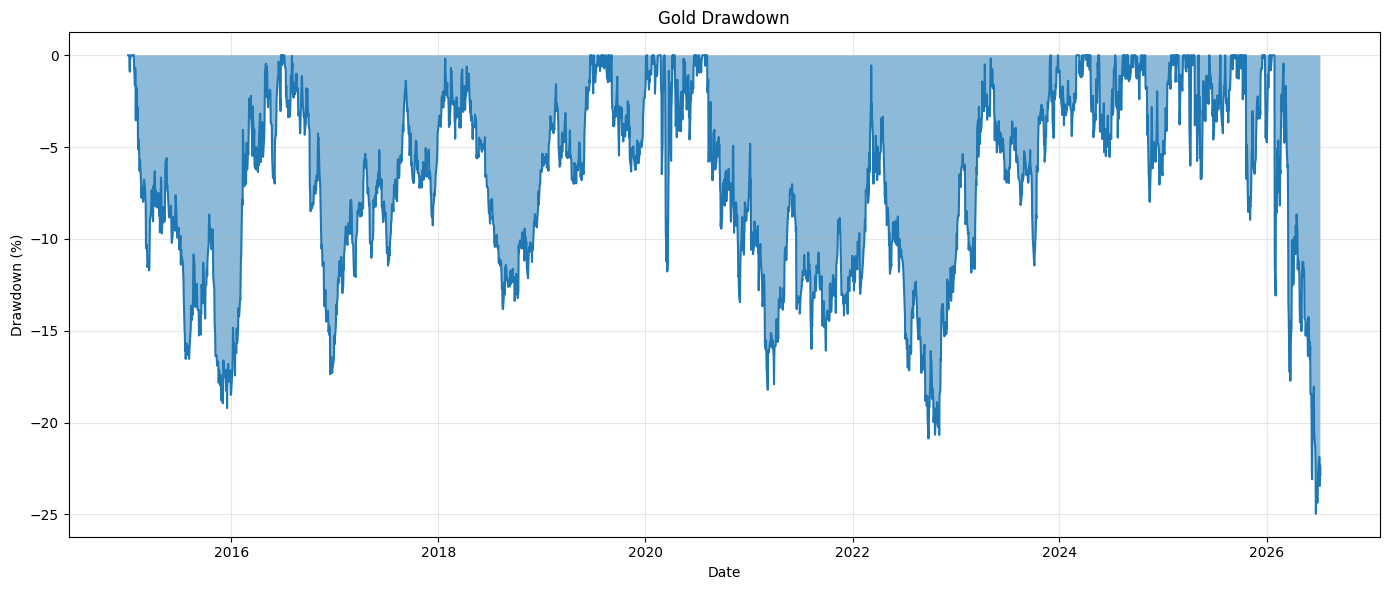

In [14]:
from visualisation import plot_drawdown

plot_drawdown(
    drawdown_data["gold"],
    "Gold"
)

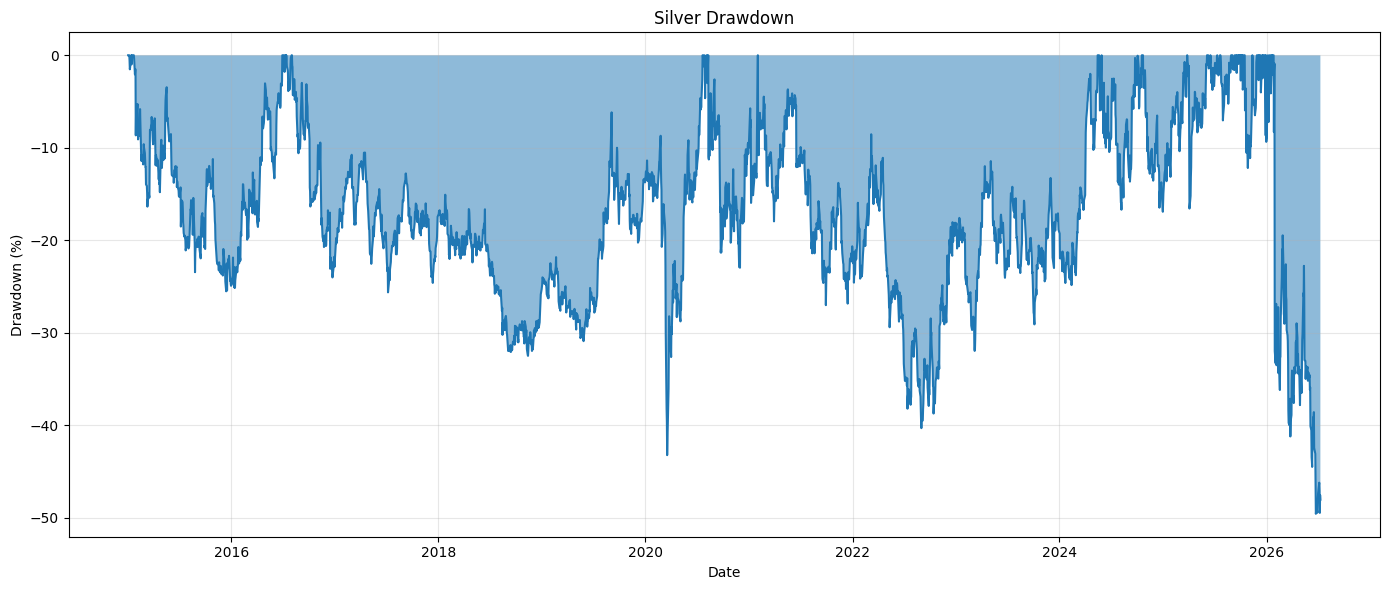

In [16]:
plot_drawdown(drawdown_data["silver"], "Silver")



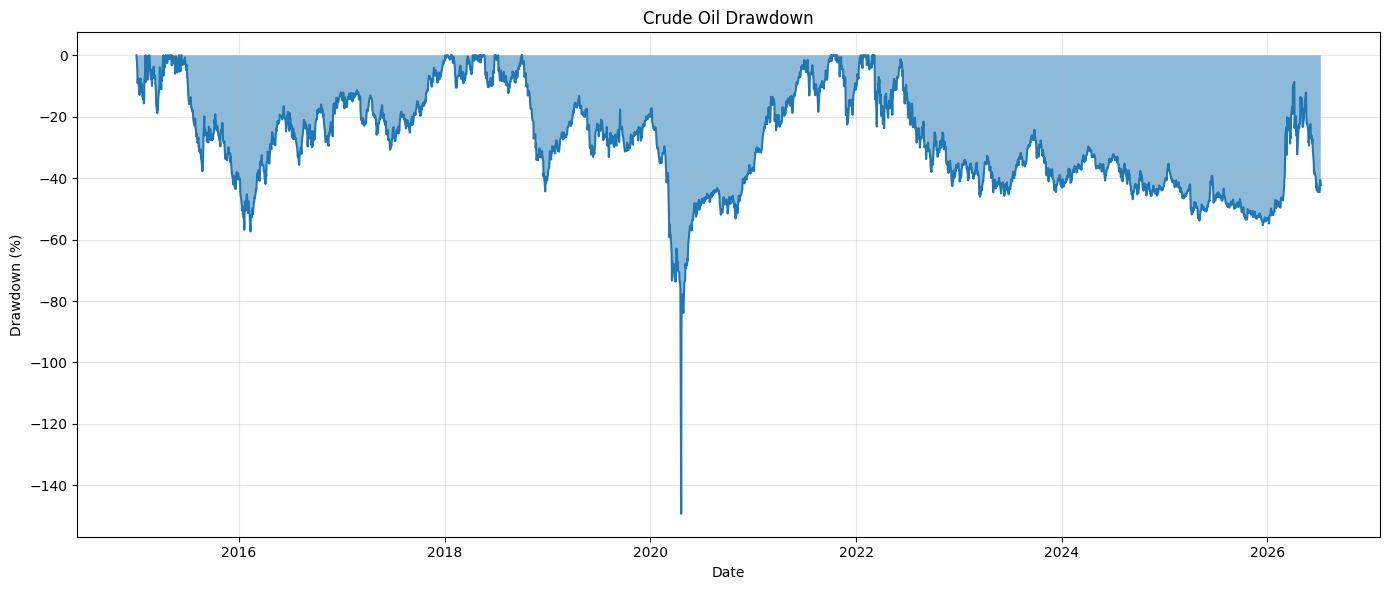

In [15]:
plot_drawdown(drawdown_data["crude_oil"], "Crude Oil")

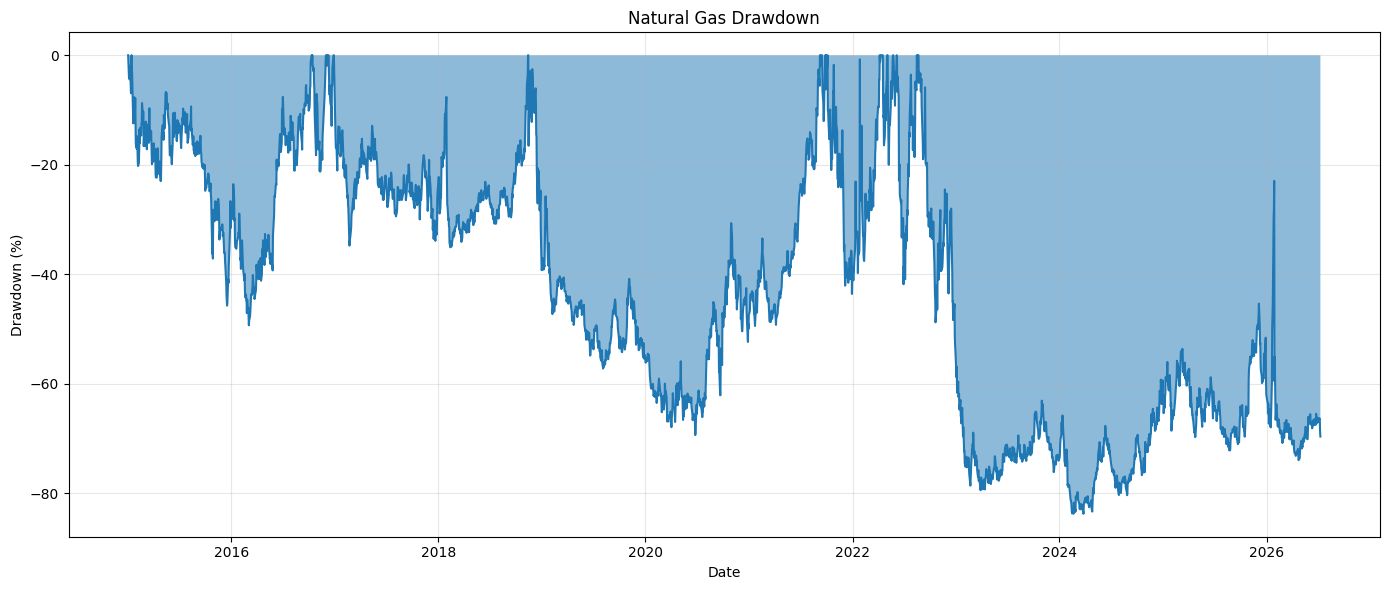

In [17]:
plot_drawdown(drawdown_data["natural_gas"], "Natural Gas")


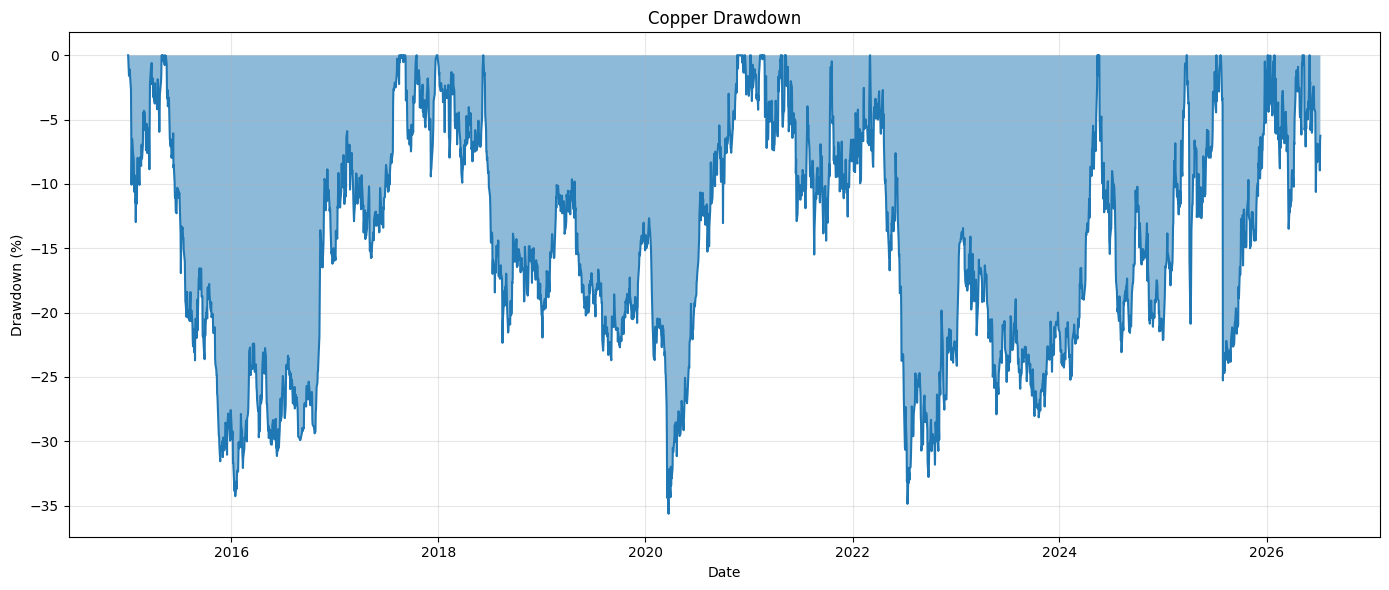

In [18]:
plot_drawdown(drawdown_data["copper"], "Copper")

# Drawdown Curve Analysis

## Business Question

Drawdown curves show how far a commodity falls below its previous all-time high, helping assess the severity and duration of market declines beyond simple return and volatility measures.

---

## Key Observations

### 🥇 Gold
- Gold experienced the smallest and shortest drawdowns among all commodities.
- Most corrections remained within **-20%**, demonstrating strong resilience.
- A larger correction emerged toward mid-2026, pushing drawdown beyond **-25%**.

### 🥈 Silver
- Silver underwent substantially deeper corrections than gold.
- The largest drawdown approached **-50%**, reflecting its higher volatility.
- Recovery periods were generally longer after major market declines.

### 🛢️ Crude Oil
- Crude oil recorded the most extreme drawdown due to the historic **negative oil prices in April 2020**.
- Apart from this anomaly, oil frequently experienced prolonged drawdowns between **-20% and -50%**.
- This highlights the commodity's exposure to severe market shocks.

### 🔥 Natural Gas
- Natural gas displayed long-lasting and cyclical drawdowns.
- Extended periods below **-60%** indicate slow recoveries following major price collapses.
- The commodity remained one of the least resilient throughout the analysis period.

### 🏭 Copper
- Copper exhibited moderate cyclical drawdowns, typically reaching **-30% to -35%** during economic slowdowns.
- Unlike energy commodities, copper generally recovered more quickly after market corrections.

---

## Overall Insights

- **Gold** showed the strongest resilience with the shallowest drawdowns.
- **Copper** maintained moderate downside risk and relatively quick recoveries.
- **Silver** delivered larger gains but required investors to withstand much deeper losses.
- **Natural Gas** experienced prolonged periods below previous highs.
- **Crude Oil** suffered the most severe drawdown due to the unprecedented 2020 market collapse, making it the highest-risk commodity in terms of downside exposure.

Rolling Sharpe Ratio
Business Question

Which commodity consistently provides the best return for the amount of risk taken over time?

A single Sharpe ratio summarizes the whole period, but market conditions change. A rolling Sharpe ratio helps identify periods when a commodity offered strong or weak risk-adjusted performance.

In [29]:
import importlib
import analytics

importlib.reload(analytics)

<module 'analytics' from 'C:\\Users\\ujjwa\\OneDrive\\Documents\\commodity-analytics\\src\\analytics.py'>

In [22]:
from analytics import rolling_sharpe_ratio

In [23]:
sharpe_data = {}

for name, df in commodities.items():
    sharpe_data[name] = rolling_sharpe_ratio(df)

In [20]:
import importlib
import visualisation

importlib.reload(visualisation)

<module 'visualisation' from 'C:\\Users\\ujjwa\\OneDrive\\Documents\\commodity-analytics\\src\\visualisation.py'>

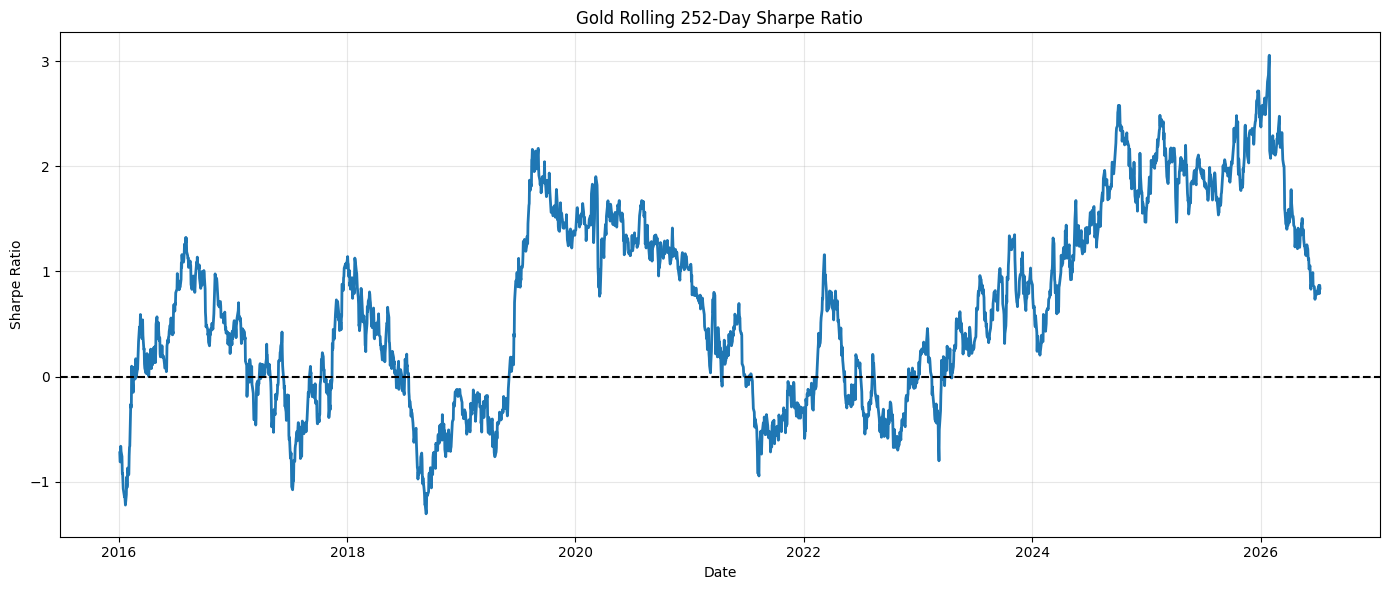

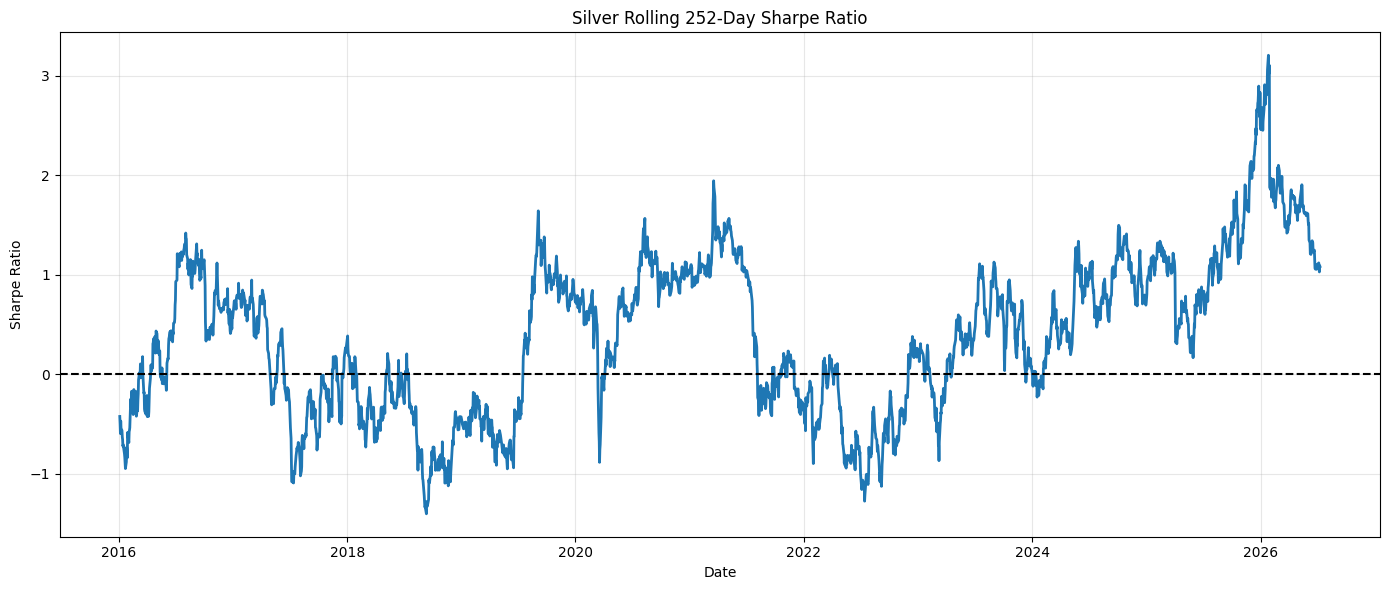

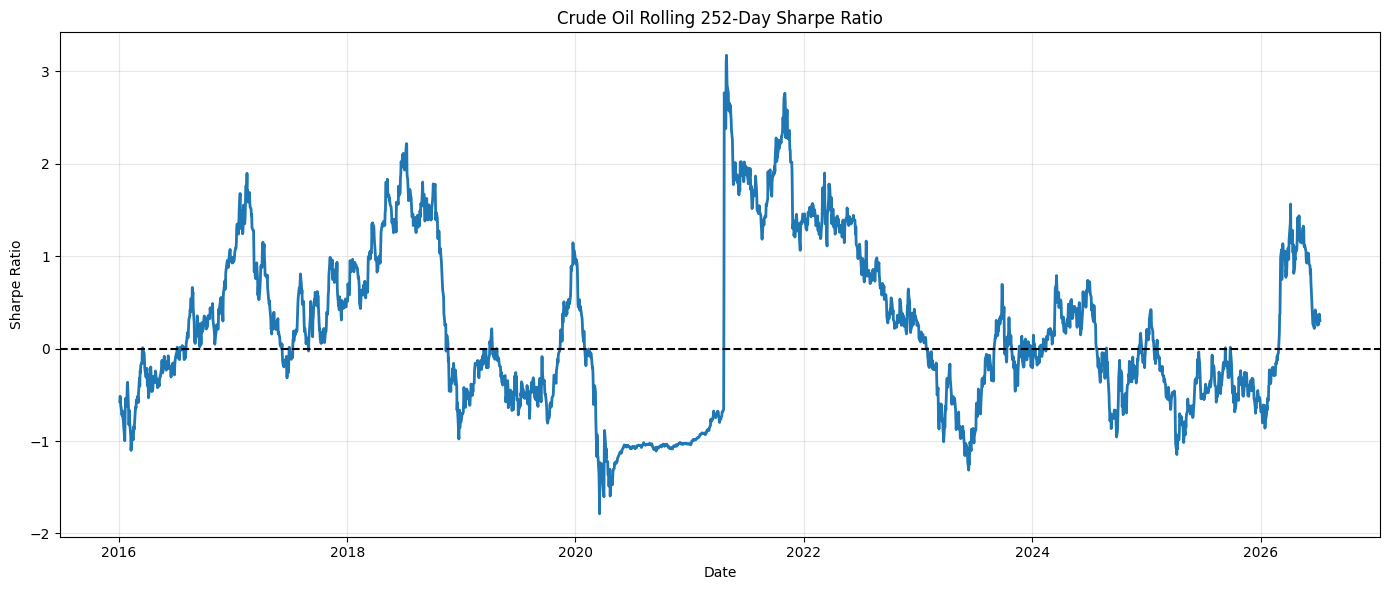

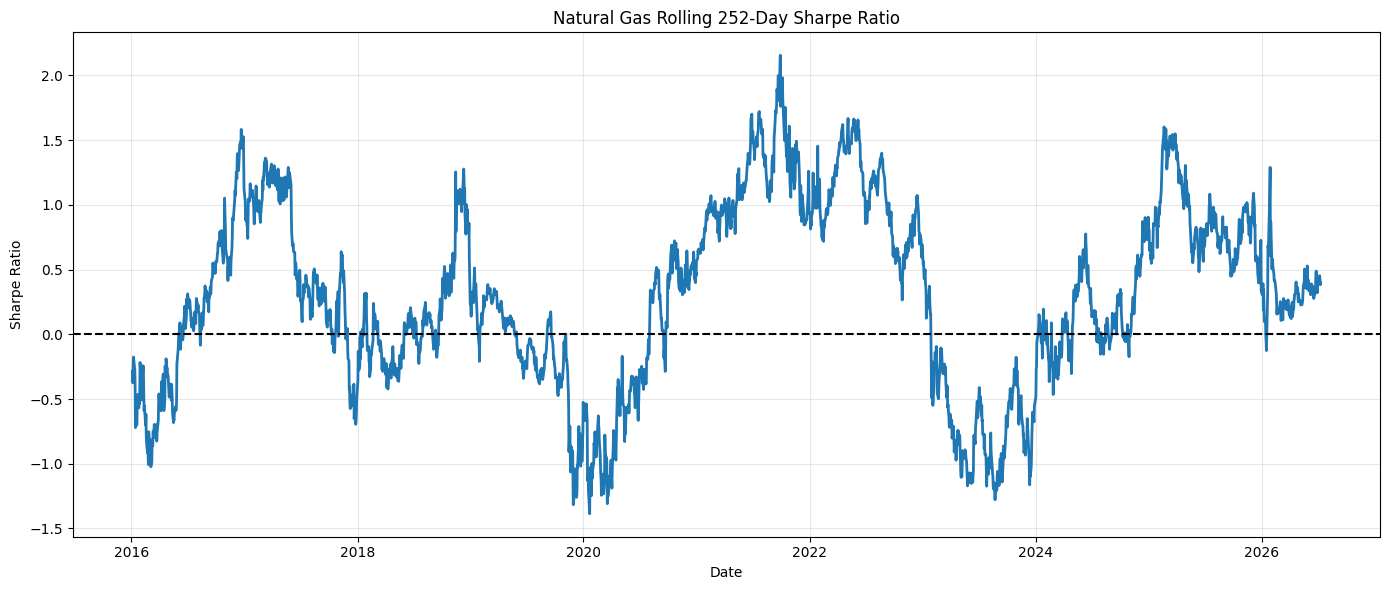

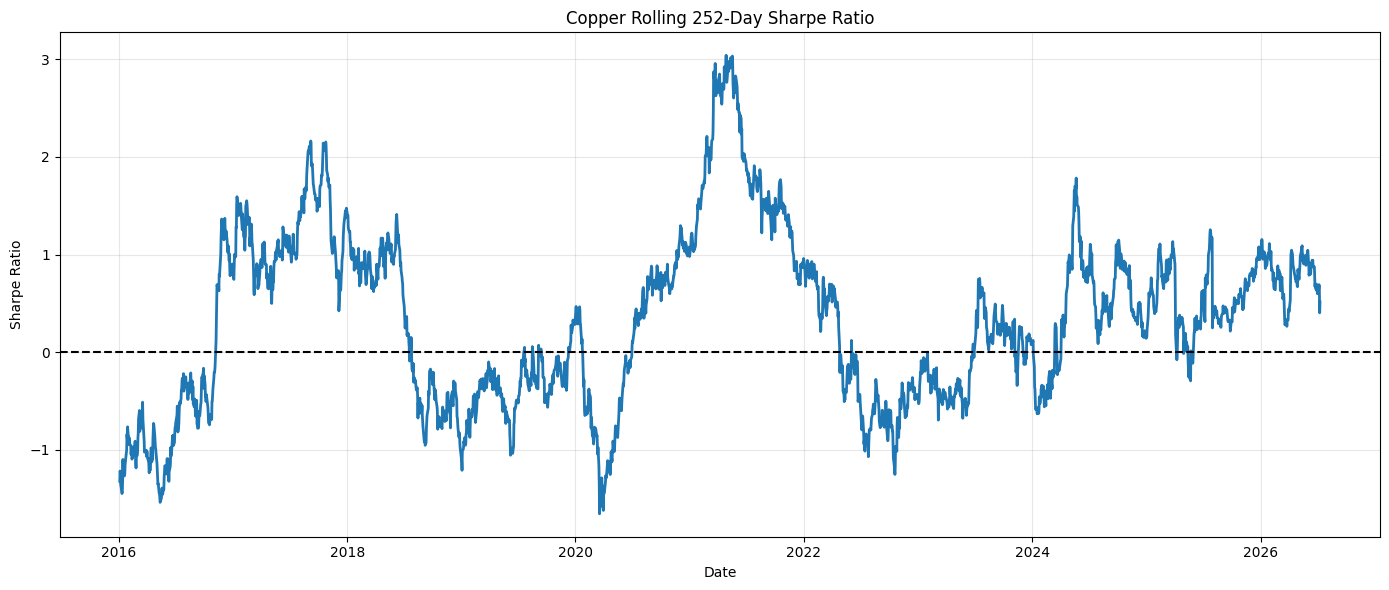

In [24]:
from visualisation import plot_rolling_sharpe

plot_rolling_sharpe(sharpe_data["gold"], "Gold")
plot_rolling_sharpe(sharpe_data["silver"], "Silver")
plot_rolling_sharpe(sharpe_data["crude_oil"], "Crude Oil")
plot_rolling_sharpe(sharpe_data["natural_gas"], "Natural Gas")
plot_rolling_sharpe(sharpe_data["copper"], "Copper")

In [27]:
from analytics import rolling_sharpe_summary

In [28]:
rolling_summary = []

for name, df in sharpe_data.items():

    result = rolling_sharpe_summary(df)

    result["Commodity"] = name

    rolling_summary.append(result)

rolling_summary = pd.DataFrame(rolling_summary)

rolling_summary

,Average Rolling Sharpe,Maximum Rolling Sharpe,Minimum Rolling Sharpe,Commodity
0,0.67,3.06,-1.31,gold
1,0.38,3.20,-1.40,silver
2,0.19,3.17,-1.79,crude_oil
3,0.30,2.16,-1.39,natural_gas
4,0.34,3.04,-1.65,copper


## Key Observations

- **Gold** achieved the highest average rolling Sharpe ratio, indicating the most consistent risk-adjusted performance throughout the analysis period.
- **Silver** occasionally delivered the strongest short-term risk-adjusted returns, but its higher volatility reduced its long-term average.
- **Copper** maintained relatively stable performance, balancing moderate returns with controlled risk.
- **Natural Gas** exhibited inconsistent performance, with periods of both positive and negative risk-adjusted returns.
- **Crude Oil** showed the weakest average rolling Sharpe ratio and the lowest minimum value, reflecting its sensitivity to major market shocks.

---

## Overall Insights

The rolling Sharpe ratio highlights that **risk-adjusted performance varies significantly over time** rather than remaining constant.

- **Gold** consistently offered the best balance between return and risk.
- **Silver** produced exceptional performance during favorable market conditions but experienced larger fluctuations.
- **Copper** provided relatively stable risk-adjusted returns.
- **Natural Gas** and **Crude Oil** displayed highly variable performance, emphasizing the challenges of investing in energy commodities during periods of market uncertainty.

DownSide Risk (Sortino Ratio):
Business Question

Which commodity generated the highest return relative to downside risk?

Unlike the Sharpe Ratio, the Sortino Ratio considers only negative returns, providing a clearer measure of performance from an investor's perspective.

In [30]:
from analytics import calculate_sortino_ratio

In [31]:
sortino_summary = []

for name, df in commodities.items():

    ratio = calculate_sortino_ratio(df)

    sortino_summary.append({
        "Commodity": name,
        "Sortino Ratio": round(ratio, 2)
    })

sortino_summary = pd.DataFrame(sortino_summary)

sortino_summary

,Commodity,Sortino Ratio
0,gold,0.80
1,silver,0.56
2,crude_oil,-0.14
3,natural_gas,0.44
4,copper,0.44




- **Gold** achieved the highest Sortino Ratio, indicating the strongest return relative to downside risk.
- **Silver** offered attractive returns but experienced larger downside fluctuations, reducing its overall Sortino Ratio.
- **Copper** and **Natural Gas** produced similar downside-adjusted performance, although natural gas remained considerably more volatile.
- **Crude Oil** recorded a negative Sortino Ratio, reflecting poor performance after accounting for downside risk and the impact of severe market disruptions.

---

## Overall Insights

The Sortino Ratio confirms that considering only harmful volatility reinforces the earlier findings from the Sharpe Ratio analysis.

- **Gold** remains the strongest performer from a downside risk perspective, providing the most favorable balance between return and potential losses.
- **Silver** continues to deliver higher return potential but requires investors to tolerate greater downside risk.
- **Copper** demonstrates moderate and relatively stable downside-adjusted performance.
- **Natural Gas** offers limited compensation for its downside risk despite periods of positive returns.
- **Crude Oil** remains the weakest commodity on a downside-adjusted basis due to its exposure to extreme market shocks.

Overall, the analysis suggests that precious metals, particularly **gold**, provide superior downside-adjusted investment performance compared with energy commodities over the study period.